In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
pd.options.display.max_columns = 100
pd.options.display.max_colwidth = 200
pd.options.display.max_rows = 100

In [3]:
xls_internal_path = "cibil_score/Internal_Bank_Dataset.xlsx"
xls_external_path = "cibil_score/External_Cibil_Dataset.xlsx"

In [4]:
df_internal = pd.read_excel("cibil_score/Internal_Bank_Dataset.xlsx")

In [5]:
df_external = pd.read_excel("cibil_score/External_Cibil_Dataset.xlsx")

In [6]:
df_internal.columns

Index(['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL',
       'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M',
       'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl',
       'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M',
       'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
       'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
       'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL'],
      dtype='str')

In [7]:
df_external.columns

Index(['PROSPECTID', 'time_since_recent_payment',
       'time_since_first_deliquency', 'time_since_recent_deliquency',
       'num_times_delinquent', 'max_delinquency_level',
       'max_recent_level_of_deliq', 'num_deliq_6mts', 'num_deliq_12mts',
       'num_deliq_6_12mts', 'max_deliq_6mts', 'max_deliq_12mts',
       'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std', 'num_std_6mts',
       'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt',
       'num_dbt_6mts', 'num_dbt_12mts', 'num_lss', 'num_lss_6mts',
       'num_lss_12mts', 'recent_level_of_deliq', 'tot_enq', 'CC_enq',
       'CC_enq_L6m', 'CC_enq_L12m', 'PL_enq', 'PL_enq_L6m', 'PL_enq_L12m',
       'time_since_recent_enq', 'enq_L12m', 'enq_L6m', 'enq_L3m',
       'MARITALSTATUS', 'EDUCATION', 'AGE', 'GENDER', 'NETMONTHLYINCOME',
       'Time_With_Curr_Empr', 'pct_of_active_TLs_ever',
       'pct_opened_TLs_L6m_of_L12m', 'pct_currentBal_all_TL', 'CC_utilization',
       'CC_Flag', 'PL_utilization', 'PL_Fla

In [8]:
df = pd. merge ( df_internal, df_external, how ='inner', left_on = ['PROSPECTID'], right_on = ['PROSPECTID'] )

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

print(categorical_cols)

Index(['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2',
       'first_prod_enq2', 'Approved_Flag'],
      dtype='str')


In [10]:
len(categorical_cols)

6

In [11]:
categorical_cols = [
    'MARITALSTATUS',
    'EDUCATION',
    'GENDER',
    'last_prod_enq2',
    'first_prod_enq2',
    'approved_flag'
]

In [12]:
# Target
y = df['Credit_Score']

# Features
X = df.drop(['Credit_Score', 'Approved_Flag'], axis=1)

# Find categorical columns
categorical_cols = X.select_dtypes(include=['object', 'string']).columns

# One-hot encode
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Verify
print(X.select_dtypes(include=['object', 'string']).columns)

Index([], dtype='str')


In [13]:
results = []

In [14]:
features = X.columns.tolist()

for i in range(1, len(features) + 1):

    # Select first i features
    selected_features = features[:i]

    X_subset = X[selected_features]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_subset,
        y,
        test_size=0.2,
        random_state=42
    )

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # R²
    r2 = r2_score(y_test, y_pred)

    # Mean Squared Error (Loss)
    mse = mean_squared_error(y_test, y_pred)

    # Adjusted R²
    n = len(y_test)
    p = X_subset.shape[1]

    adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

    # Store results
    results.append([
        i,
        selected_features[-1],
        mse,
        r2,
        adjusted_r2
    ])

In [15]:

results_df = pd.DataFrame(
    results,
    columns=[
        "No_of_Features",
        "Last_Feature_Added",
        "Loss(MSE)",
        "R2",
        "Adjusted_R2"
    ]
)

results_df

,No_of_Features,Last_Feature_Added,Loss(MSE),R2,Adjusted_R2
0,1,PROSPECTID,418.476898,-0.000439,-0.000537
1,2,Total_TL,403.945599,0.034300,0.034112
2,3,Tot_Closed_TL,403.125582,0.036260,0.035979
3,4,Tot_Active_TL,403.125582,0.036260,0.035885
4,5,Total_TL_opened_L6M,378.869256,0.094249,0.093808
5,6,Tot_TL_closed_L6M,378.450545,0.095250,0.094721
6,7,pct_tl_open_L6M,372.818742,0.108714,0.108106
7,8,pct_tl_closed_L6M,371.593386,0.111643,0.110951
8,9,pct_active_tl,364.588712,0.128389,0.127625
9,10,pct_closed_tl,364.588712,0.128389,0.127540


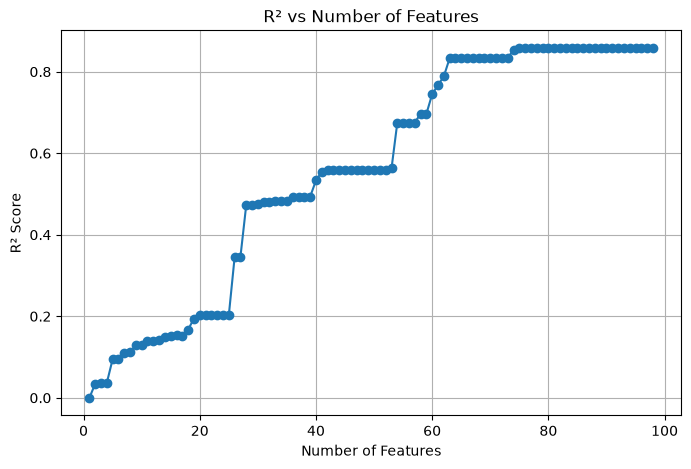

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results_df["No_of_Features"],
    results_df["R2"],
    marker='o'
)

plt.xlabel("Number of Features")
plt.ylabel("R² Score")
plt.title("R² vs Number of Features")
plt.grid(True)

plt.show()

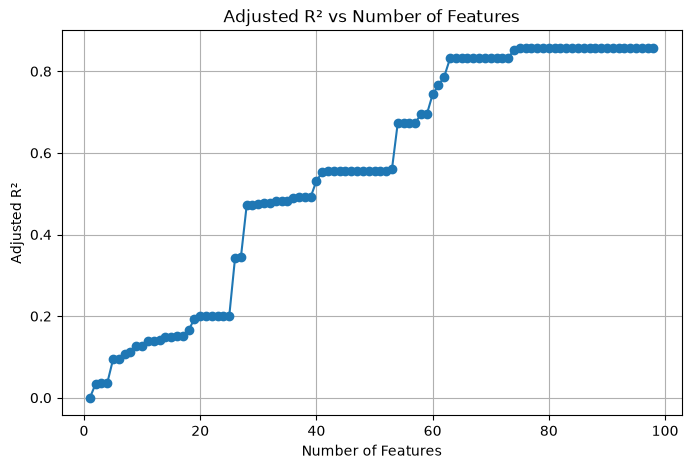

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["No_of_Features"],
    results_df["Adjusted_R2"],
    marker='o'
)

plt.xlabel("Number of Features")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² vs Number of Features")
plt.grid(True)

plt.show()

In [18]:
results_df.sort_values(
    by="R2",
    ascending=False
)

,No_of_Features,Last_Feature_Added,Loss(MSE),R2,Adjusted_R2
92,93,last_prod_enq2_others,59.346217,0.858123,0.856826
89,90,last_prod_enq2_ConsumerLoan,59.347811,0.858119,0.856864
90,91,last_prod_enq2_HL,59.349004,0.858116,0.856847
91,92,last_prod_enq2_PL,59.350754,0.858112,0.856829
94,95,first_prod_enq2_ConsumerLoan,59.353831,0.858105,0.856779
93,94,first_prod_enq2_CC,59.357736,0.858095,0.856784
74,75,pct_CC_enq_L6m_of_L12m,59.358486,0.858094,0.857049
79,80,GL_Flag,59.368305,0.858070,0.856955
80,81,MARITALSTATUS_Single,59.369043,0.858068,0.856940
96,97,first_prod_enq2_PL,59.370662,0.858064,0.856711


Conclusion: 

some few features have very low or even negative R² values like

PROSPECTID	-0.0004

Total_TL	0.0343

Tot_Closed_TL	0.0363

Tot_Active_TL 0.0363

indicating that they are weak individual predictors
---------------------------------------------------------

A noticeable increase in R² occurs after adding features related to:

Enquiry history (enq_L6m, enq_L3m)

Credit utilization (CC_utilization, PL_utilization)

Delinquency information

Recent enquiry details

Loan flags (CC_Flag, PL_Flag, HL_Flag, GL_Flag)

These variables have a much stronger relationship with the target.
-----------------------------------------------------------------

Model performance improved as more features were added.
The R² score increased continuously from -0.0004 to 0.8581
-----------------------------------------------------

Delinquency-related features significantly improved the model.

Features such as:

num_times_delinquent

max_delinquency_level

num_deliq_6mts

num_deliq_12mts

recent_level_of_deliq

produced a noticeable increase in R².

Conclusion: A customer's repayment history and delinquency behaviour are strong indicators of credit score.

------------------------------------------------------------------------

Enquiry-related features are among the most important predictors.

Features including:

enq_L3m

enq_L6m

enq_L12m

time_since_recent_enq

tot_enq

substantially improved the model performance.

Conclusion: Recent credit enquiries have a strong influence on predicting credit score.
-------------------------------------------------------------------

Credit utilization features contributed significantly.

Important features include:

CC_utilization

PL_utilization

These features increased the R² score considerably.

Conclusion: Higher or lower utilization of available credit plays an important role in determining a customer's credit score.

Loan type indicator (Flag) features also improved prediction.

Examples:
CC_Flag
PL_Flag
HL_Flag
GL_Flag
These variables improved model performance, indicating that the types of loans a customer holds provide useful information about creditworthiness.
----------------------------------------------------------------------------

MARITALSTATUS
GENDER
EDUCATION
These features were added near the end of the process and produced only marginal improvements in R².
Conclusion: Customer personal information contributes less to predicting credit score than financial behaviour.
--------------------------------------------------------------------------------------------

Adjusted R² remained almost constant after adding the last few features.

Final Adjusted R² ≈ 0.8568
Since Adjusted R² penalizes unnecessary features, the almost constant value indicates that the last few variables contribute very little additional information.
---------------------------------------------------------------------------------

The Linear Regression model achieved an R² of 0.8581, indicating that approximately 85.8% of the variation in credit score is explained by the selected features. Beyond approximately 75–80 features, the improvement in R² and Adjusted R² became negligible, suggesting that a smaller subset of well-chosen features could achieve nearly the same predictive performance while keeping the model simpler and more efficient.